In [1]:
from scipy.stats import median_abs_deviation

import sys
sys.path.insert(0, '/home/workspace/mm_bm_chip_organoids')
sys.path.insert(0, '/home/workspace/')

from py_util import *
from utilities import *

hdir = '/home/workspace'
wdir = hdir + "/mm_bm_chip_organoids/EXP-01440"
objdir1 = wdir + "/object_building/objects/"
objdir2 = wdir + "/processing/objects/"

raw_adata = sc.read_h5ad(objdir1 + "not_ds_all_organoids_adata.h5ad")
# adata = sc.read_h5ad(objdir2 + "not_ds_processed_all_organoids_adata.h5ad")

In [14]:
meta = "sample"

samples = list(raw_adata.obs[meta].unique())

filtered_adatas = {}

for sample in samples:
    print(f"Processing sample: {sample}")
    mask = raw_adata.obs[meta] == sample
    sample_adata = raw_adata[mask].copy()
    
    print(f"Initial shape: {sample_adata.shape}")
    
    sample_adata.var["mt"] = sample_adata.var_names.str.startswith("MT-")
    sample_adata.var["ribo"] = sample_adata.var_names.str.startswith(("RPS", "RPL"))
    sample_adata.var["hb"] = sample_adata.var_names.str.contains(("^HB[^(P)]"))
    
    print(f"After adding var annotations: {sample_adata.shape}")
    
    sc.pp.calculate_qc_metrics(sample_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True)
    
    print(f"After calculating QC metrics: {sample_adata.shape}")
    
    sample_adata.obs["mt_outlier"] = sample_adata.obs['pct_counts_mt'] >= 10
    
    print(f"Before Scrublet - X shape: {sample_adata.X.shape}")
    
    # Continue with your code...

    print(list(sample_adata.obs['sample'].unique()))
    
    # Run Scrublet for doublet detection
    scrub = scrublet.Scrublet(sample_adata.X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(verbose=False)
    
    # Add Scrublet results to cell metadata
    sample_adata.obs['doublet_score'] = doublet_scores
    sample_adata.obs['predicted_doublet'] = predicted_doublets

    # Filtering outliers
    sample_adata = sample_adata[(sample_adata.obs["predicted_doublet"] == False) & (sample_adata.obs["mt_outlier"] == False)].copy()

    filtered_adatas[sample_adata.obs[meta].unique()[0]] = sample_adata.copy()

adata = ad.concat(filtered_adatas.values(), join='outer', merge='same')

# Store log1p transformed normalized counts
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Saving raw adata
adata.raw = adata

# Standard processing workflow
sc.pp.highly_variable_genes(adata)
sc.pp.scale(adata)
sc.pp.pca(adata)

# Harmonizing data based on sample type
X = adata.obsm['X_pca'].astype(np.float64)
harmony_out = hm.run_harmony(X, adata.obs, 'sample')
adata.obsm['X_pca'] = harmony_out.Z_corr.T

sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Computing a range of leiden resolutions from 0-2 in increments of 0.1
res_range = np.round(np.arange(0, 2.2, 0.1), 1)
for res in res_range:
    sc.tl.leiden(
        adata,
        flavor="igraph",
        key_added=f"leiden_{str(res).replace('.', '_')}",
        n_iterations=2,
        resolution=res
    )

adata.uns['leiden_ranges'] = [f'leiden_{i:.1f}'.replace('.', '_') for i in np.arange(0, 2.1, 0.1)]

leiden_res = 'leiden_0_8'

adata.obs['leiden'] = adata.obs[leiden_res].copy()
adata.uns['leiden'] = adata.uns[leiden_res].copy()

sc.tl.paga(adata, groups='leiden')
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# adata.write(objdir2 + 'not_ds_processed_all_organoids_adata.h5ad', compression='gzip')

Processing sample: BMC07965-007
Initial shape: (2366, 18082)
After adding var annotations: (2366, 18082)
After calculating QC metrics: (2366, 18082)
Before Scrublet - X shape: (2366, 18082)
['BMC07965-007']
(2366, 139)
Processing sample: BMC09023-003
Initial shape: (1369, 18082)
After adding var annotations: (1369, 18082)
After calculating QC metrics: (1369, 18082)
Before Scrublet - X shape: (1369, 18082)
['BMC09023-003']
(1369, 671)
Processing sample: BMC09025-003
Initial shape: (941, 18082)
After adding var annotations: (941, 18082)
After calculating QC metrics: (941, 18082)
Before Scrublet - X shape: (941, 18082)
['BMC09025-003']
(941, 559)
Processing sample: CELL01173
Initial shape: (11943, 18082)
After adding var annotations: (11943, 18082)
After calculating QC metrics: (11943, 18082)
Before Scrublet - X shape: (11943, 18082)
['CELL01173']
(11943, 1409)
Processing sample: CELL01174
Initial shape: (4470, 18082)
After adding var annotations: (4470, 18082)
After calculating QC metric

ValueError: n_components=30 must be between 1 and min(n_samples, n_features)=2 with svd_solver='arpack'

In [10]:
meta = "sample"

samples = list(raw_adata.obs[meta].unique())

filtered_adatas = {}

for sample in samples:
    mask = raw_adata.obs[meta] == sample
    sample_adata = raw_adata[mask].copy()
    
    sample_adata.var["mt"] = sample_adata.var_names.str.startswith("MT-")                 # mitochondrial genes
    sample_adata.var["ribo"] = sample_adata.var_names.str.startswith(("RPS", "RPL"))      # ribosomal genes
    sample_adata.var["hb"] = sample_adata.var_names.str.contains(("^HB[^(P)]"))           # hemoglobin genes
    
    sc.pp.calculate_qc_metrics(sample_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True)
    
    sample_adata.obs["mt_outlier"] = sample_adata.obs['pct_counts_mt'] >= 10

    print(list(sample_adata.obs['sample'].unique()))
    
    # Run Scrublet for doublet detection
    scrub = scrublet.Scrublet(sample_adata.X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(verbose=False)
    
    # Add Scrublet results to cell metadata
    sample_adata.obs['doublet_score'] = doublet_scores
    sample_adata.obs['predicted_doublet'] = predicted_doublets

    # Filtering outliers
    sample_adata = sample_adata[(sample_adata.obs["predicted_doublet"] == False) & (sample_adata.obs["mt_outlier"] == False)].copy()

    filtered_adatas[sample_adata.obs[meta].unique()[0]] = sample_adata.copy()

adata = ad.concat(filtered_adatas.values(), join='outer', merge='same')

# Store log1p transformed normalized counts
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Saving raw adata
adata.raw = adata

# Standard processing workflow
sc.pp.highly_variable_genes(adata)
sc.pp.scale(adata)
sc.pp.pca(adata)

# Harmonizing data based on sample type
X = adata.obsm['X_pca'].astype(np.float64)
harmony_out = hm.run_harmony(X, adata.obs, 'sample')
adata.obsm['X_pca'] = harmony_out.Z_corr.T

sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Computing a range of leiden resolutions from 0-2 in increments of 0.1
res_range = np.round(np.arange(0, 2.2, 0.1), 1)
for res in res_range:
    sc.tl.leiden(
        adata,
        flavor="igraph",
        key_added=f"leiden_{str(res).replace('.', '_')}",
        n_iterations=2,
        resolution=res
    )

adata.uns['leiden_ranges'] = [f'leiden_{i:.1f}'.replace('.', '_') for i in np.arange(0, 2.1, 0.1)]

leiden_res = 'leiden_0_8'

adata.obs['leiden'] = adata.obs[leiden_res].copy()
adata.uns['leiden'] = adata.uns[leiden_res].copy()

sc.tl.paga(adata, groups='leiden')
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

adata.write(objdir2 + 'not_ds_processed_all_organoids_adata.h5ad', compression='gzip')

['BMC07965-007']
(2366, 139)
['BMC09023-003']
(1369, 671)
['BMC09025-003']
(941, 559)
['CELL01173']
(11943, 1409)
['CELL01174']
(4470, 1605)
['CELL01176']
(5017, 1602)
['OR00005']
(8365, 2)


ValueError: n_components=30 must be between 1 and min(n_samples, n_features)=2 with svd_solver='arpack'

# Sample Type UMAP

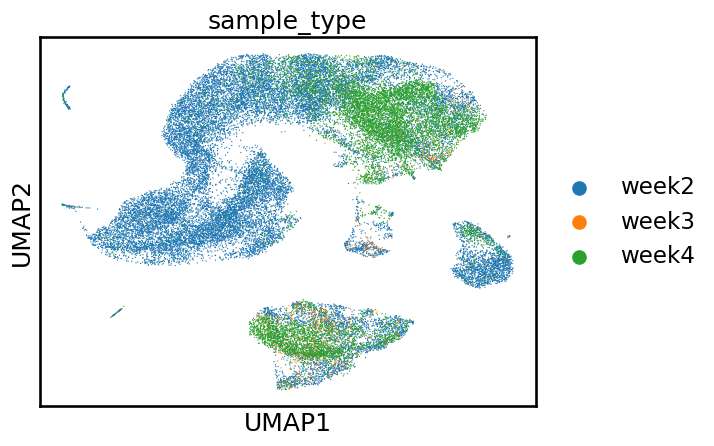

In [9]:
sc.pl.umap(
    adata,
    color='sample_type'
)

# Leiden UMAPs

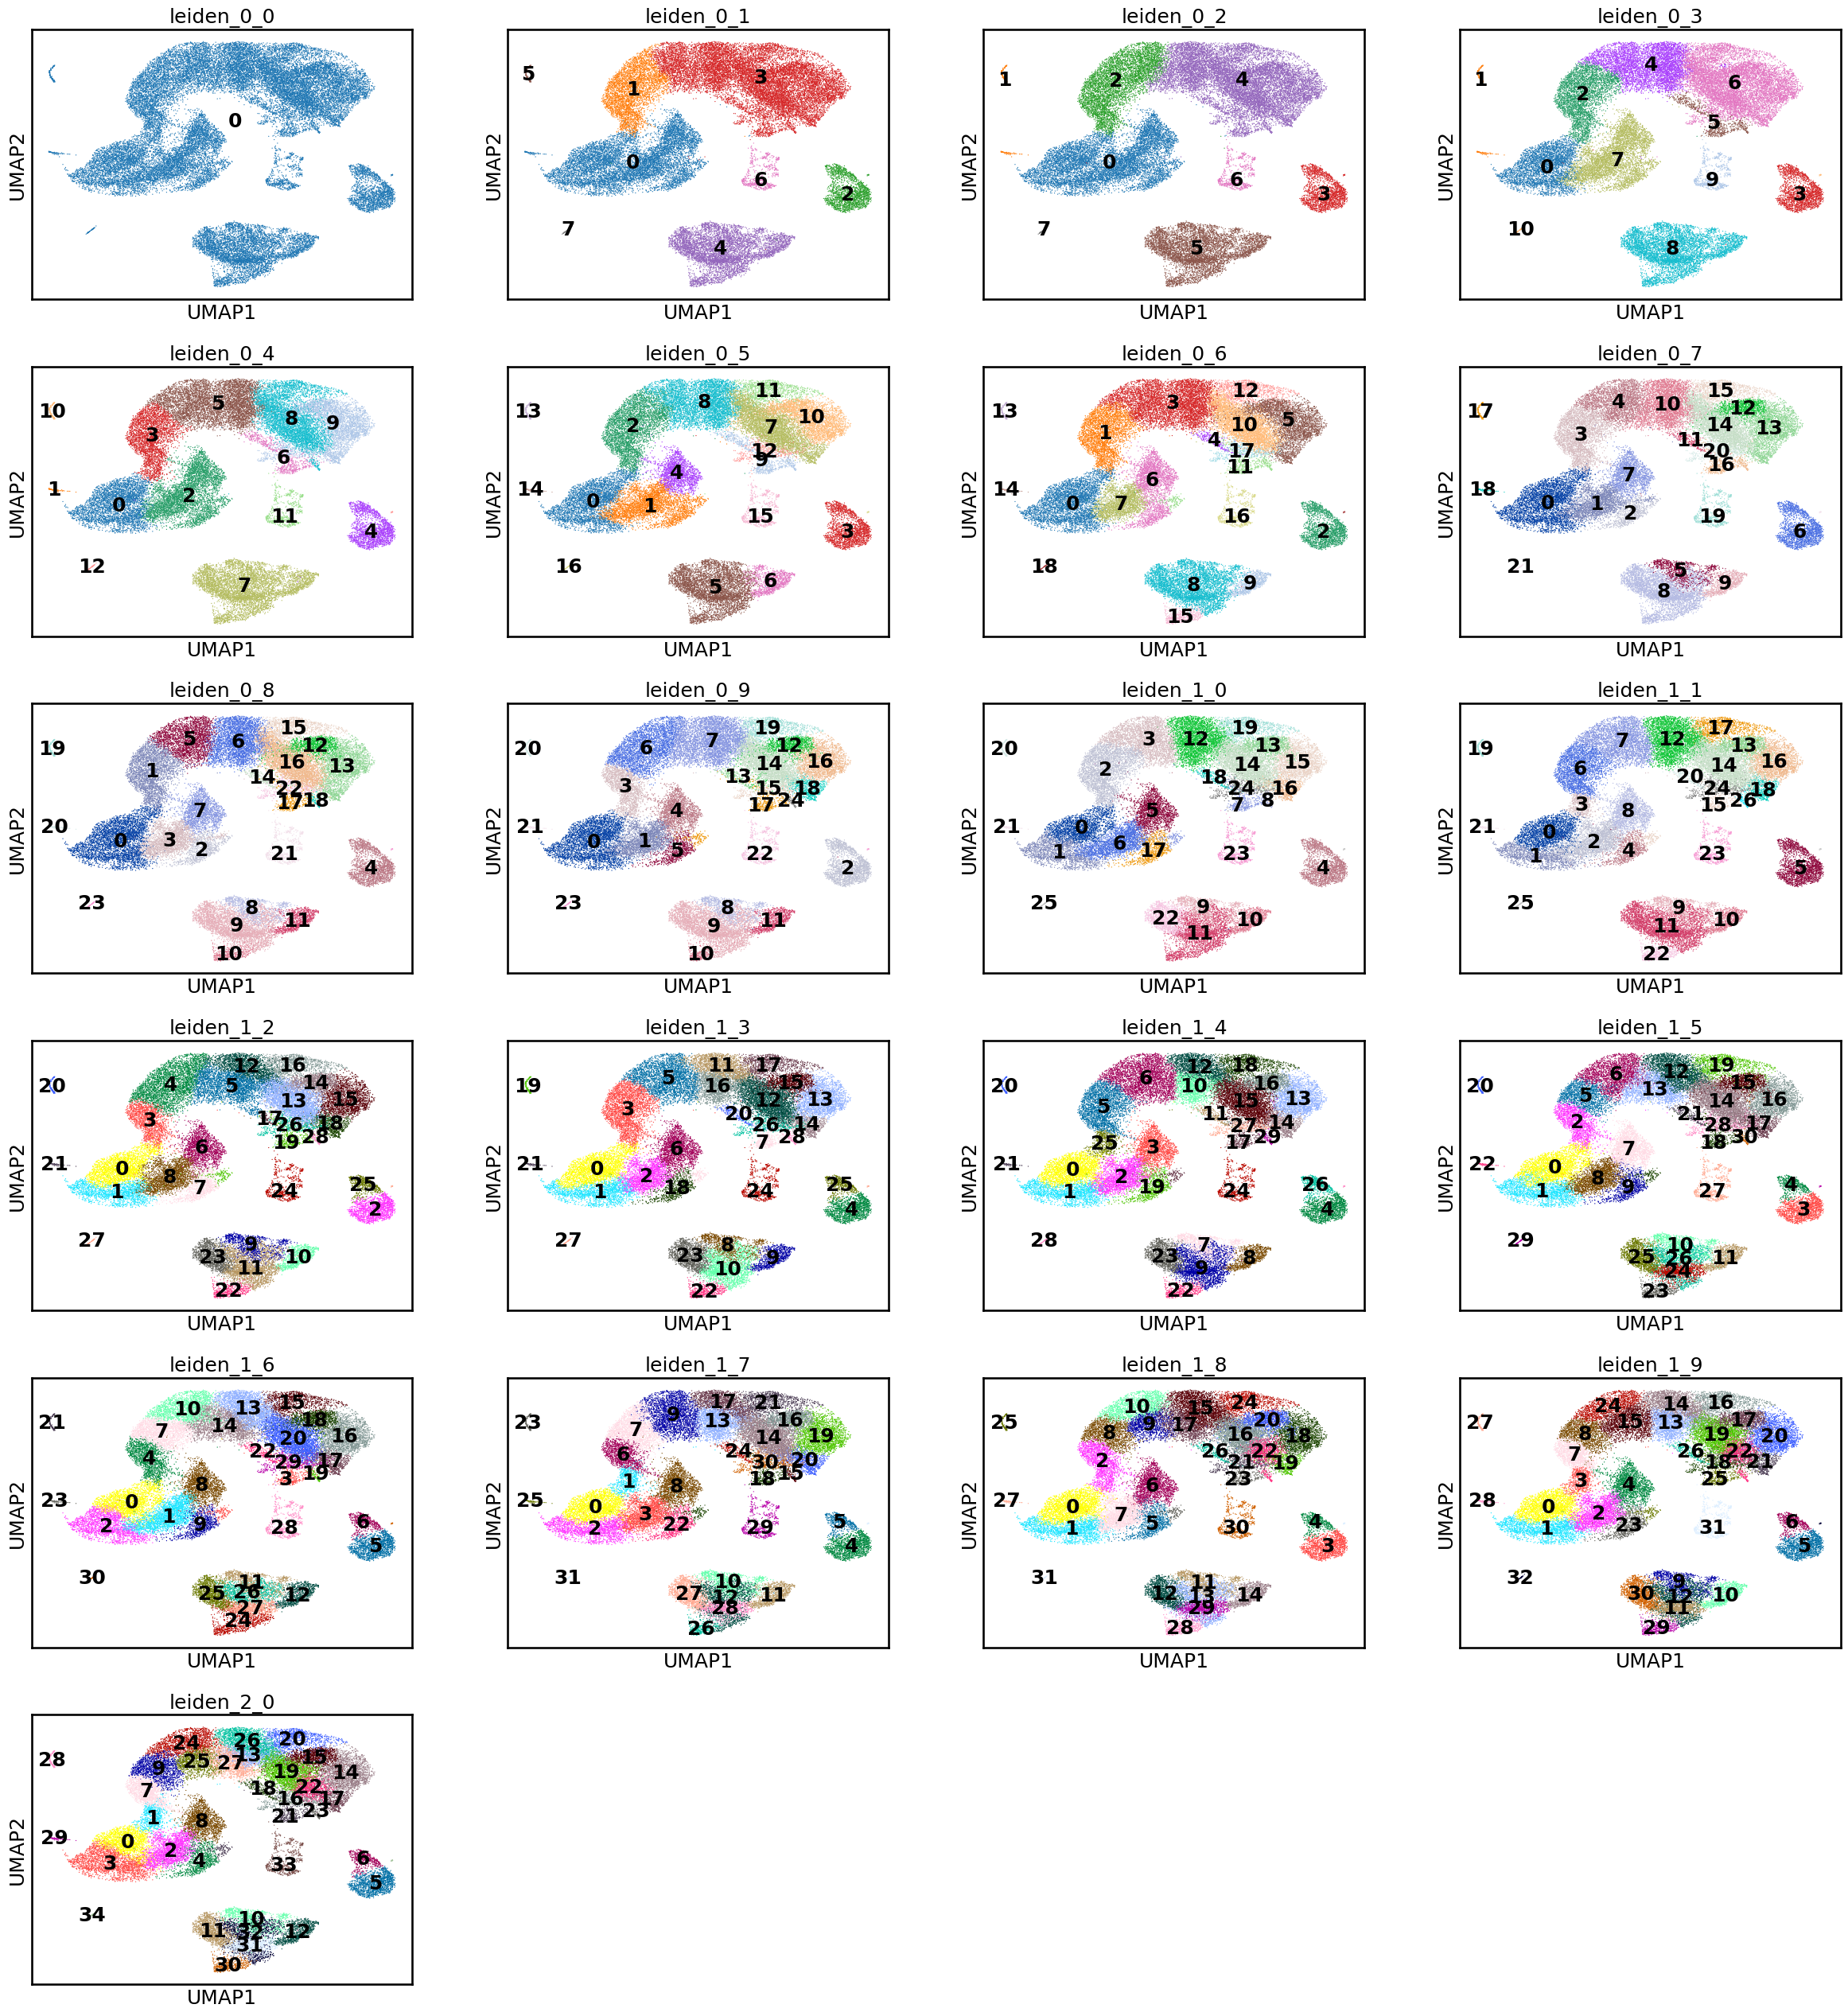

In [10]:
sc.pl.umap(
    adata,
    color=adata.uns['leiden_ranges'],
    legend_loc='on data'
)